Total rows: 220
Species x Color found in CSV:
species  color
cat      black     38
         gray      16
dog      brown    142
         white     24

Subgroups to evaluate: ['cat_black', 'cat_gray', 'dog_brown', 'dog_white']

Plot colors assigned:
  cat    / black    → #1a1a1a
  cat    / gray     → #5c5c5c
  dog    / brown    → #c8a882
  dog    / white    → #d9d9d9
=> merge config from /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/Swin-Unet/vendor/Swin-Unet/configs/swin_tiny_patch4_window7_224_lite.yaml
Loading Swin-Unet pretrained weights from /home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/Swin-Unet/vendor/Swin-Unet/pretrained_ckpt/swin_tiny_patch4_window7_224.pth
SwinTransformerSys expand initial----depths:[2, 2, 2, 2];depths_decoder:[1, 2, 2, 2];drop_path_rate:0.2;num_classes:3
---final upsample expand_first---
pretrained_path:/home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/Swin-Unet/vendor/Swin-Unet/pretrained_ckpt/swin_tiny_patch4_window7_224.pth
---start l

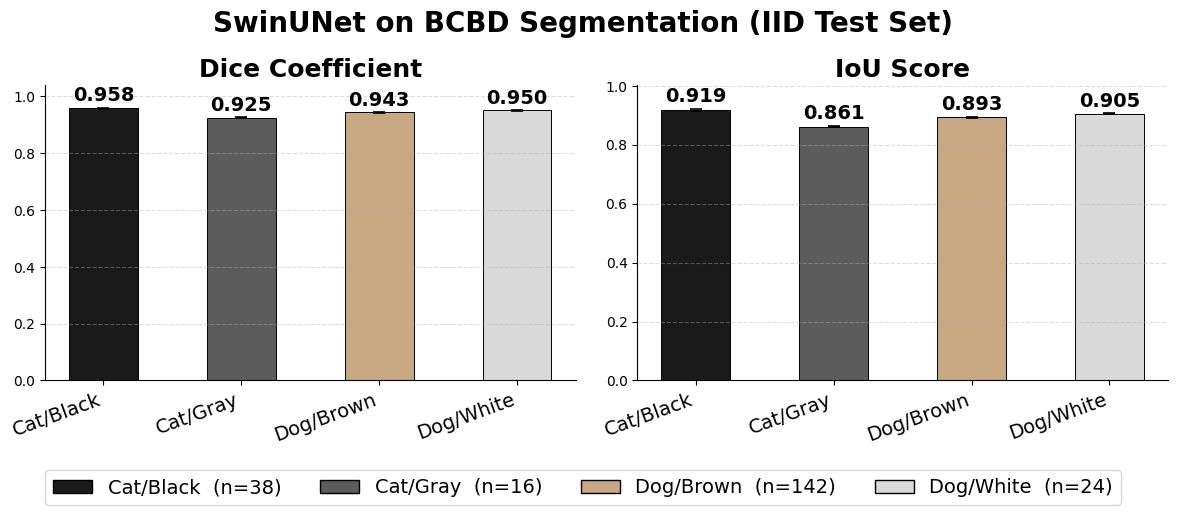

Plot saved → test_subgroup_accuracy.png


In [ ]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch.nn.functional as F
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from collections import defaultdict
import albumentations as A
from albumentations.pytorch import ToTensorV2
from swinunet_model import build_swinunet, DEFAULT_PRETRAINED, DEFAULT_CFG
CFG_PATH = str(DEFAULT_CFG)
ALL_TEST_CSV = "/home/ahsan/test-project/ISIC-2019/Pet_data/pet_fixed_by_label/Metadata/Metadata_final/Cat_black_grey_Dog_brown_white_test_IID.csv"
PET_DATA_ROOT = "/home/ahsan/test-project/ISIC-2019/Pet_data/pet_fixed_by_label"
LR_INITIAL = 1e-4
SPECIES_TO_CLASS = {"background": 0, "cat": 1, "dog": 2}
NUM_CLASSES      = 3
BATCH_SIZE       = 8
VIT_NAME = "R50-ViT-B_16"
N_SKIP = 3
DEVICE           = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
IMG_SIZE = 224
PRETRAINED_PATH = str(DEFAULT_PRETRAINED)
SEEDS = [22, 42, 123]
EPOCHS = 100
CHECKPOINT_DIR = "/home/ahsan/test-project/ISIC-2019/ISIC_Multiclass_Seg/Swin-Unet/pets_checkpoints/multiseed"

val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

# ── Load CSV 
df_all = pd.read_csv(ALL_TEST_CSV)
df_all.columns    = df_all.columns.str.strip()
df_all["species"] = df_all["species"].str.lower().str.strip()
df_all["color"]   = df_all["color"].str.lower().str.strip()

print(f"Total rows: {len(df_all)}")
print(f"Species x Color found in CSV:")
print(df_all.groupby(["species", "color"]).size().to_string())

# ── Build SUBGROUPS dynamically from whatever is in the CSV 
SUBGROUPS = [
    {"species": sp, "color": col}
    for (sp, col) in df_all.groupby(["species", "color"]).groups.keys()
]
subgroup_names = [f"{s['species']}_{s['color']}" for s in SUBGROUPS]
print(f"\nSubgroups to evaluate: {subgroup_names}")


COLOR_MAP = {
    "black" : "#1a1a1a",
    "grey"  : "#5c5c5c",
    "gray"  : "#5c5c5c",
    "white" : "#d9d9d9",
    "brown" : "#c8a882",
    "other" : "#bdbdbd",
}
GRAYSCALE_FALLBACK = ["#1a1a1a", "#5c5c5c", "#d9d9d9", "#c8a882", "#bdbdbd"]

PLOT_COLOR = {}
for i, sg in enumerate(SUBGROUPS):
    key = (sg["species"], sg["color"])
    PLOT_COLOR[key] = COLOR_MAP.get(sg["color"], GRAYSCALE_FALLBACK[i % len(GRAYSCALE_FALLBACK)])

print(f"\nPlot colors assigned:")
for k, v in PLOT_COLOR.items():
    print(f"  {k[0]:6s} / {k[1]:8s} → {v}")

# ── Dataset 
class PetSubgroupDataset(Dataset):
    def __init__(self, sub_df, data_root, transform=None):
        self.df        = sub_df.reset_index(drop=True)
        self.data_root = data_root
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row       = self.df.iloc[idx]
        img_path  = os.path.join(self.data_root, row["image"])
        mask_path = os.path.join(self.data_root, row["mask"])
        species   = str(row["species"]).lower().strip()

        image       = np.array(Image.open(img_path).convert("RGB"))
        binary_mask = np.array(Image.open(mask_path).convert("L")) > 127
        species_cls = SPECIES_TO_CLASS[species]
        mask        = np.zeros(binary_mask.shape, dtype=np.int64)
        mask[binary_mask] = species_cls

        if self.transform:
            aug   = self.transform(image=image, mask=mask)
            image = aug["image"]
            mask  = aug["mask"]

        if not isinstance(mask, torch.Tensor):
            mask = torch.as_tensor(mask)
        if mask.ndim == 3:
            mask = mask.squeeze(0)
        if mask.is_floating_point():
            mask = mask.round()

        return image, mask.long()

# ── Metrics 
def compute_metrics(outputs, masks, num_classes, smooth=1e-6):
    """
    outputs : [B, C, H, W] raw logits
    masks   : [B, H, W]    long ground truth
    """
    preds = outputs.argmax(dim=1) # [B, H, W]

    acc = (preds == masks).float().mean().item()

    preds_flat = preds.view(-1)   # [B * H * W]
    masks_flat = masks.view(-1)   # [B * H * W]

    preds_one_hot = F.one_hot(preds_flat, num_classes=num_classes).float()
    masks_one_hot = F.one_hot(masks_flat, num_classes=num_classes).float()

    inter = (preds_one_hot * masks_one_hot).sum(dim=0)
    total_preds = preds_one_hot.sum(dim=0)
    total_masks = masks_one_hot.sum(dim=0)
    union = total_preds + total_masks - inter

    inter = inter[1:]
    union = union[1:]
    total_preds = total_preds[1:]
    total_masks = total_masks[1:]

    class_present = (total_masks > 0)

    if class_present.sum() == 0:
        return {"acc": acc, "dice": 0.0, "iou": 0.0}

    dice_per_class = (2 * inter + smooth) / (total_preds + total_masks + smooth)
    iou_per_class = (inter + smooth) / (union + smooth)

    mean_dice = dice_per_class[class_present].mean().item()
    mean_iou = iou_per_class[class_present].mean().item()

    return {
        "acc"  : acc,
        "dice" : mean_dice,
        "iou"  : mean_iou,
    }

def evaluate_loader(model, loader):
    tot_acc = tot_dice = tot_iou = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(DEVICE), masks.to(DEVICE)
            outputs = model(images)
            m = compute_metrics(outputs, masks, NUM_CLASSES)
            tot_acc  += m["acc"]
            tot_dice += m["dice"]
            tot_iou  += m["iou"]
    n_batches = len(loader)
    if n_batches == 0:
        return {"acc": 0.0, "dice": 0.0, "iou": 0.0}
    return {
        "acc"  : tot_acc  / n_batches,
        "dice" : tot_dice / n_batches,
        "iou"  : tot_iou  / n_batches,
    }

subgroup_loaders = {}
for sg in SUBGROUPS:
    species = sg["species"]
    color   = sg["color"]
    key     = f"{species}_{color}"
    label   = f"{species.capitalize()}/{color.capitalize()}"
    sub_df  = df_all[(df_all["species"] == species) & (df_all["color"] == color)]
    dataset = PetSubgroupDataset(sub_df, PET_DATA_ROOT, transform=val_transform)
    loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=4, pin_memory=True)
    subgroup_loaders[key] = {
        "loader"  : loader,
        "label"   : label,
        "species" : species,
        "color"   : color,
        "n"       : len(sub_df),
    }

model = build_swinunet(
    num_classes     = NUM_CLASSES,
    img_size        = IMG_SIZE,
    cfg_path        = CFG_PATH,
    pretrained_path = PRETRAINED_PATH,
    device          = DEVICE,
)
DEVICE = torch.device('cuda:1' if torch.cuda.is_available() else 'cpu')
model.to(DEVICE)

# ── Multi-seed evaluation 
per_seed_results = []
for seed in SEEDS:
    ckpt = f"{CHECKPOINT_DIR}/SwinUNet_Pets_multiclass_seed{seed}_epoch{EPOCHS}.pth"
    if not os.path.exists(ckpt):
        print(f"Skipping seed {seed}: {ckpt} not found")
        continue
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.eval()
    print(f"\n{'#'*65}\n  Evaluating seed {seed}\n{'#'*65}")
    seed_results = {}
    for key, info in subgroup_loaders.items():
        m = evaluate_loader(model, info["loader"])
        seed_results[key] = m
        print(f"  {info['label']:<18}  Dice={m['dice']:.4f}  IoU={m['iou']:.4f}")
    per_seed_results.append(seed_results)

results = {}
for key, info in subgroup_loaders.items():
    dice_vals = [sr[key]["dice"] for sr in per_seed_results if key in sr]
    iou_vals  = [sr[key]["iou"]  for sr in per_seed_results if key in sr]
    results[key] = {
        "label"     : info["label"],
        "species"   : info["species"],
        "color"     : info["color"],
        "n"         : info["n"],
        "dice"      : float(np.mean(dice_vals)) if dice_vals else 0.0,
        "dice_std"  : float(np.std(dice_vals, ddof=1)) if len(dice_vals) > 1 else 0.0,
        "iou"       : float(np.mean(iou_vals))  if iou_vals  else 0.0,
        "iou_std"   : float(np.std(iou_vals, ddof=1)) if len(iou_vals) > 1 else 0.0,
    }

print("\n" + "="*65)
print(f"{'Subgroup':<18} {'N':>5} {'Dice':>22} {'IoU':>22}")
print("="*65)
for key, m in results.items():
    print(f"{m['label']:<18} {m['n']:>5} "
          f"{m['dice']:.4f} ± {m['dice_std']:.4f}   "
          f"{m['iou']:.4f} ± {m['iou_std']:.4f}")
print("="*65)

# ── Plot 
keys       = list(results.keys())
labels     = [results[k]["label"] for k in keys]
bar_colors = [PLOT_COLOR[(results[k]["species"], results[k]["color"])] for k in keys]
x          = np.arange(len(keys))

metrics_cfg = [
    ("dice", "Dice Coefficient"),
    ("iou",  "IoU Score"),
]

fig, axes = plt.subplots(1, 2, figsize=(max(12, len(keys) * 2.5), 5))
fig.suptitle("SwinUNet on BCBD Segmentation (IID Test Set)", fontsize=20, fontweight='bold')

for ax, (metric, title) in zip(axes, metrics_cfg):
    values = [results[k][metric] for k in keys]
    stds   = [results[k][f"{metric}_std"] for k in keys]
    bars   = ax.bar(
        x, values, yerr=stds, capsize=4,
        color=bar_colors, edgecolor='black', linewidth=0.7, width=0.5,
        error_kw=dict(elinewidth=1.2, capthick=1.2, ecolor='black'),
    )

    ymax = max((v + s for v, s in zip(values, stds)), default=1.0)
    ax.set_ylim(0, min(1.25, ymax + 0.08))
    label_offset = 0.01

    for bar, val, std in zip(bars, values, stds):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + std + label_offset,
            f"{val:.3f}",
            ha='center', va='bottom', fontsize=14, fontweight='bold'
        )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=14)
    ax.set_title(title, fontsize=18, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend with sample counts
legend_handles = [
    mpatches.Patch(
        facecolor=PLOT_COLOR[(results[k]["species"], results[k]["color"])],
        edgecolor='black',
        label=f"{results[k]['label']}  (n={results[k]['n']})"
    )
    for k in keys
]
fig.legend(
    handles=legend_handles,
    loc='lower center',
    ncol=min(len(keys), 5),          # max 5 per row
    bbox_to_anchor=(0.5, -0.03),
    fontsize=14, frameon=True
)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("test_subgroup_accuracy.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved → test_subgroup_accuracy.png")